In [26]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
#from GEOS5functions import *
import datetime
from scipy.ndimage import rotate
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds


In [27]:
%run GEOS5functions.py

In [28]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

# Set the current storm index to 0
currentstorm = 77

# Reminder of what's in stormlist      
            stormlist[0][tccount] = tccount
            stormlist[1][tccount] = name
            stormlist[2][tccount] = name[0:3] # basin identifier
            stormlist[3][tccount] = dtstart
            stormlist[4][tccount] = dtend
            stormlist[5][tccount] = lat1
            stormlist[6][tccount] = lat2
            stormlist[7][tccount] = lon1
            stormlist[8][tccount] = lon2

In [10]:
stormlist[1][currentstorm][0:9]

'npc06tc01'

In [11]:
# Retrieve the start and end times of the current storm from the stormlist
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]

# Retrieve the latitude and longitude bounds of the current storm from the stormlist
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

# Create a slice object for selecting data based on the start time
timesel = slice(starttime, starttime)

# Define a buffer (in degrees) to expand the geographical bounds around the storm
degbuffer = 10

# Create slice objects for selecting data based on latitude and longitude bounds with buffer
latsel = slice(lat1 - degbuffer, lat2 + degbuffer)
lonsel = slice(lon1 - degbuffer, lon2 + degbuffer)

In [12]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'DELP']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url)  # Open dataset for 'V' (meridional wind component)
    if varvec[vind] == 'DELP':
        dsdelp = xr.open_dataset(url)  # Open dataset for 'DELP' (surface pressure and pressure thickness)

# Print a success message indicating that the datasets have been read successfully
print('success reading')

# URL for accessing the land mask dataset
landurl = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/const/const_2d_asm_Nx'
# Open the land mask dataset
dsland = xr.open_dataset(landurl)

# Display the land mask dataset information
dsdelp

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


<xarray.Dataset> Size: 177TB
Dimensions:  (time: 36576, lev: 72, lat: 2881, lon: 5760)
Coordinates:
  * time     (time) datetime64[ns] 293kB 2005-05-15T21:30:00.000003 ... 2007-...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * lat      (lat) float64 23kB -90.0 -89.94 -89.88 -89.81 ... 89.88 89.94 90.0
  * lon      (lon) float64 46kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
Data variables:
    delp     (time, lev, lat, lon) float32 175TB ...
    ps       (time, lat, lon) float32 2TB ...
Attributes:
    title:                3d,30-Minute,Instantaneous,Model-Level,Full Resolut...
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Wed Apr 22 15:17:33 GMT 2026 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...

In [13]:
# Select latitude and longitude data from the dataset using the latitude and longitude bounds defined by latsel and lonsel
lat = dsdelp['lat'].sel(lat=latsel)
lon = dsdelp['lon'].sel(lon=lonsel)

# Select surface pressure data from the dsdelp dataset for the specified time and geographical bounds
ps = dsdelp['ps'].sel(time=timesel, lat=latsel, lon=lonsel)

# Select the ocean flag data from the dsland dataset for the specified geographical bounds
ocnflag = dsland.frocean.sel(lat=latsel, lon=lonsel)

In [14]:
# Processe the ps data by first removing any unnecessary singleton dimensions and then applying a mask to retain only the data points corresponding to ocean regions based on the ocnflag values.
psflag = np.squeeze(ps).where(ocnflag>0.96)

# Follower

In [18]:
for i in range(1, 2):
    
    print(i)
    
    currentstorm = i
    
    
    starttime = stormlist[3][currentstorm]
    endtime   = stormlist[4][currentstorm]
    lat1  = stormlist[5][currentstorm]
    lat2  = stormlist[6][currentstorm]
    lon1  = stormlist[7][currentstorm]
    lon2  = stormlist[8][currentstorm]

    timesel = slice(starttime,endtime)
    degbuffer = 0.5
    latsel = slice(lat1-degbuffer,lat2+degbuffer)
    lonsel = slice(lon1-degbuffer,lon2+degbuffer)
    
    lat = dsdelp['lat'].sel(lat=latsel)  # Select latitude values within the range specified by 'latsel'
    lon = dsdelp['lon'].sel(lon=lonsel)  # Select longitude values within the range specified by 'lonsel'
    time = dsdelp['time'].sel(time=timesel)  # Select time values within the range specified by 'timesel'
    lev = dsu['lev']  # Select the vertical levels (pressure levels) from the 'dsu' dataset

    # Select surface pressure ('ps') from the dataset based on the time, latitude, and longitude selections
    ps = dsdelp['ps'].sel(time=timesel, lat=latsel, lon=lonsel)

    # Select the ocean flag ('frocean') from the 'dsland' dataset based on the latitude and longitude selections
    ocnflag = dsland.frocean.sel(lat=latsel, lon=lonsel)

    # Print the shape of the 'ps' array to understand its dimensions
    print(ps.shape)
    
    minplat = np.zeros(len(time))
    # Print the shape of the 'minplat' array to verify its dimensions
    print(minplat.shape)

    # Create an array of zeros with the same length as the time dimension to store minimum longitude values
    minplon = np.zeros(len(time))

    # Create an array of zeros with the same length as the time dimension to store minimum pressure values
    minpres = np.zeros(len(time))
    
    # Loop through each time step in the time array
    for tt in range(len(time)):
        if tt == 0:
            # For the first time step, select the surface pressure (ps) and ocean flag over the entire region of interest
            psnow = dsdelp['ps'].sel(time=time[tt], lat=latsel, lon=lonsel)
            ocnflag = dsland.frocean.sel(lat=latsel, lon=lonsel)

            # Mask the ps values to only include ocean regions (where ocnflag > 0.96)
            psflag = np.squeeze(psnow).where(ocnflag > 0.96).squeeze()
        if tt > 0:
            # For subsequent time steps, update the lat and lon selections to focus around the previous minimum pressure location
            psnow = dsdelp['ps'].sel(time=time[tt], lat=lattrans, lon=lontrans)
            ocnflag = dsland.frocean.sel(lat=lattrans, lon=lontrans)

            # Mask the ps values to only include ocean regions
            psflag = np.squeeze(psnow).where(ocnflag > 0.96).squeeze()

        # Store the minimum pressure at the current time step in the minpres array
        minpres[tt] = psflag.min()    

        # Find the latitude and longitude corresponding to the minimum pressure
        minlat = psnow[:,:].where(psflag == minpres[tt], drop=True).lat.squeeze()
        minlon = psnow[:,:].where(psflag == minpres[tt], drop=True).lon.squeeze()

        # Handle cases where minlat or minlon might be arrays instead of single values
        if len(minlat.values.shape) == 1:
            minlat = minlat[0]
        if len(minlon.values.shape) == 1:
            minlon = minlon[0]

        # Store the latitude and longitude of the minimum pressure in the respective arrays
        minplat[tt] = minlat
        minplon[tt] = minlon

        # Define a small region (buffer) around the detected minimum pressure for the next time step's search
        degbuffer = 0.5 # Degree range around the new center
        lattrans = slice(minlat - degbuffer, minlat + degbuffer)
        lontrans = slice(minlon - degbuffer, minlon + degbuffer)

        # Print the time, minimum longitude, minimum latitude, and minimum pressure for each time step
        #print(time[tt].values, minlon.values, minlat.values, minpres[tt])

        # Clean up variables to avoid unintended carry-over
        del  psnow, ocnflag, psflag

    # minlon, minlat,

    minlat=minplat[0]
    print(minlat)
    minlon=minplon[0]
    print(minlon)
    
    filesave = stormlist[1][currentstorm][0:9]  # Get the first 9 characters of the storm's identifier
    np.savez(filesave, minplat=minplat, minplon=minplon, time=time, minpres=minpres)  # Save the data in a '.npz' file
    
    
    
    
    



1
(199, 49, 65)
(199,)
21.9375
-81.125


In [19]:
# Set the current storm index to ???
currentstorm = 1

In [20]:
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

timesel = slice(starttime,endtime)
degbuffer = 5
latsel = slice(lat1-degbuffer,lat2+degbuffer)
lonsel = slice(lon1-degbuffer,lon2+degbuffer)

In [21]:
# Select latitude, longitude, time, and level data from the datasets based on the specified slices

lat = dsdelp['lat'].sel(lat=latsel)  # Select latitude values within the range specified by 'latsel'
lon = dsdelp['lon'].sel(lon=lonsel)  # Select longitude values within the range specified by 'lonsel'
time = dsdelp['time'].sel(time=timesel)  # Select time values within the range specified by 'timesel'
lev = dsu['lev']  # Select the vertical levels (pressure levels) from the 'dsu' dataset

# Select surface pressure ('ps') from the dataset based on the time, latitude, and longitude selections
ps = dsdelp['ps'].sel(time=timesel, lat=latsel, lon=lonsel)

# Select the ocean flag ('frocean') from the 'dsland' dataset based on the latitude and longitude selections
ocnflag = dsland.frocean.sel(lat=latsel, lon=lonsel)

# Print the shape of the 'ps' array to understand its dimensions
print(ps.shape)

(199, 193, 209)


In [22]:
time.shape

(199,)

In [23]:
# Initialize arrays to store minimum pressure latitude, longitude, and pressure values for each time step

# Create an array of zeros with the same length as the time dimension to store minimum latitude values
minplat = np.zeros(len(time))
# Print the shape of the 'minplat' array to verify its dimensions
print(minplat.shape)

# Create an array of zeros with the same length as the time dimension to store minimum longitude values
minplon = np.zeros(len(time))

# Create an array of zeros with the same length as the time dimension to store minimum pressure values
minpres = np.zeros(len(time))

(199,)


In [24]:
# Loop through each time step in the time array
for tt in range(len(time)):
    if tt == 0:
        # For the first time step, select the surface pressure (ps) and ocean flag over the entire region of interest
        psnow = dsdelp['ps'].sel(time=time[tt], lat=latsel, lon=lonsel)
        ocnflag = dsland.frocean.sel(lat=latsel, lon=lonsel)
        
        # Mask the ps values to only include ocean regions (where ocnflag > 0.96)
        psflag = np.squeeze(psnow).where(ocnflag > 0.96).squeeze()
    if tt > 0:
        # For subsequent time steps, update the lat and lon selections to focus around the previous minimum pressure location
        psnow = dsdelp['ps'].sel(time=time[tt], lat=lattrans, lon=lontrans)
        ocnflag = dsland.frocean.sel(lat=lattrans, lon=lontrans)
        
        # Mask the ps values to only include ocean regions
        psflag = np.squeeze(psnow).where(ocnflag > 0.96).squeeze()
         
    # Store the minimum pressure at the current time step in the minpres array
    minpres[tt] = psflag.min()    
    
    # Find the latitude and longitude corresponding to the minimum pressure
    minlat = psnow[:,:].where(psflag == minpres[tt], drop=True).lat.squeeze()
    minlon = psnow[:,:].where(psflag == minpres[tt], drop=True).lon.squeeze()
    
    # Handle cases where minlat or minlon might be arrays instead of single values
    if len(minlat.values.shape) == 1:
        minlat = minlat[0]
    if len(minlon.values.shape) == 1:
        minlon = minlon[0]
        
    # Store the latitude and longitude of the minimum pressure in the respective arrays
    minplat[tt] = minlat
    minplon[tt] = minlon
    
    # Define a small region (buffer) around the detected minimum pressure for the next time step's search
    degbuffer = 0.5 # Degree range around the new center
    lattrans = slice(minlat - degbuffer, minlat + degbuffer)
    lontrans = slice(minlon - degbuffer, minlon + degbuffer)
    
    # Print the time, minimum longitude, minimum latitude, and minimum pressure for each time step
    #print(time[tt].values, minlon.values, minlat.values, minpres[tt])
    
    # Clean up variables to avoid unintended carry-over
    del  psnow, ocnflag, psflag

# minlon, minlat,

minlat=minplat[0]
print(minlat)
minlon=minplon[0]
print(minlon)

21.9375
-81.125


In [25]:
minlat=minplat[0]
print(minlat)
minlon=minplon[0]
print(minlon)

21.9375
-81.125


In [5]:
filesave = stormlist[1][currentstorm][0:9]  # Get the first 9 characters of the storm's identifier
#np.savez( '/home/z/zilmana/modares/TC/trajectory/' + filesave, minplat=minplat, minplon=minplon, time=time, minpres=minpres)  # Save the data in a '.npz' file

In [6]:
filesave

'npc06tc01'

In [7]:
stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(filesave)+'.npz')

In [8]:
minpres = stormtraj['minpres']
time = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

In [9]:
minpres.shape

(486,)

In [10]:
%matplotlib inline 
import matplotlib.dates as mdates

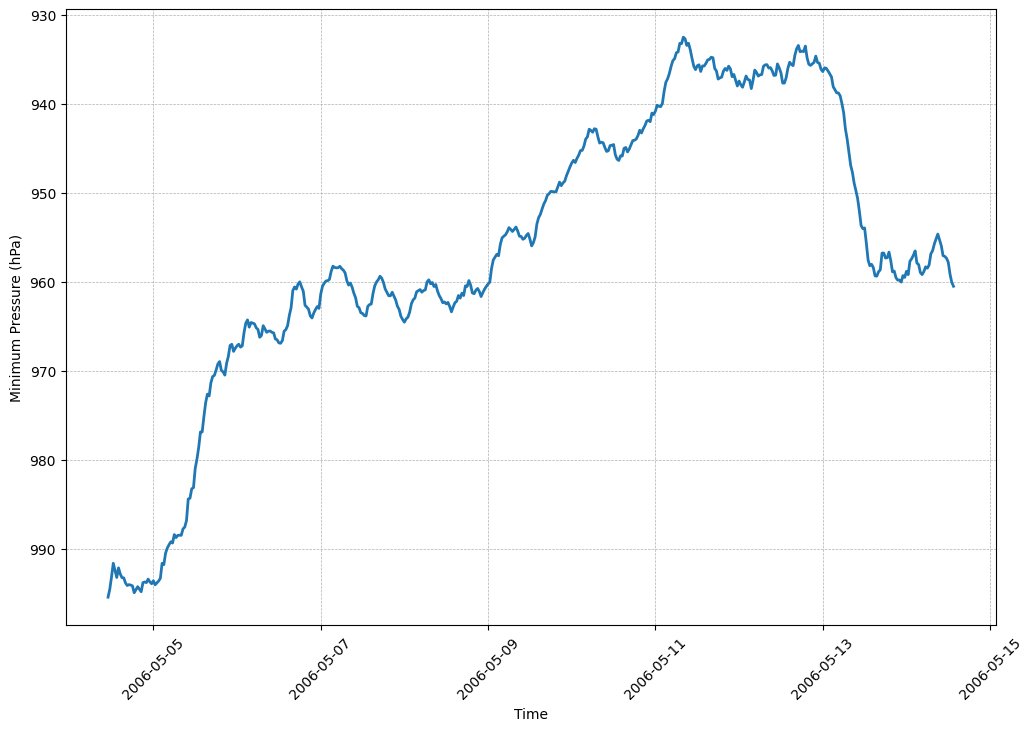

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.plot(time, minpres/100,linewidth=2 )

plt.xlabel('Time')
plt.ylabel('Minimum Pressure (hPa)')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.invert_yaxis()
plt.xticks(rotation=45)

plt.savefig('npc06tc01_intensity.png', bbox_inches='tight', transparent=True)


plt.show()

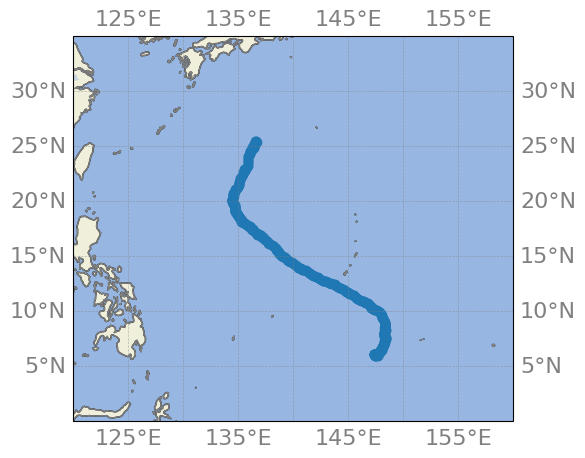

In [79]:
fig = plt.figure(figsize=(10,))
crs0 = ccrs.PlateCarree(central_longitude=0)
ax = fig.add_subplot(1, 1, 1, projection=crs0)
#ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=crs0)

#####

ax.set_extent([120, 160, 0, 35], crs=crs0)
#ax.stock_img()
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.OCEAN)

ax.add_feature(cfeature.LAND)
#####

ax.coastlines()
ax.coastlines('50m', color='gray',edgecolor='white')
gl = ax.gridlines(crs=crs0, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlabel_style = {'size':16,'color':'gray'}
gl.ylabel_style = {'size':16,'color':'gray'}

plt.scatter(minplon,minplat)


plt.savefig('npc06tc01_trajectory.png', bbox_inches='tight', transparent=True)


plt.show()